In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import healpy as hp
import h5py

In [2]:
NSIDE = 4096
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

201326592


# 1Mhz

In [3]:
with h5py.File('1.0MHz_with_absorption.hdf5','r') as fe:
    print('fe.keys()',fe.keys())
    skymap = fe['skymap'][:]
    extragalactic_point_source_catalog_intrinsic = fe['extragalactic_point_source_catalog_intrinsic'][:] 
    print('skymap',skymap)

fe.keys() <KeysViewHDF5 ['extragalactic_point_source_catalog_intrinsic', 'skymap']>
skymap [27688093.45628118 27739825.20638995 27707507.47858482 ...
 10015891.04069953 10007220.7687832  10188208.12463213]


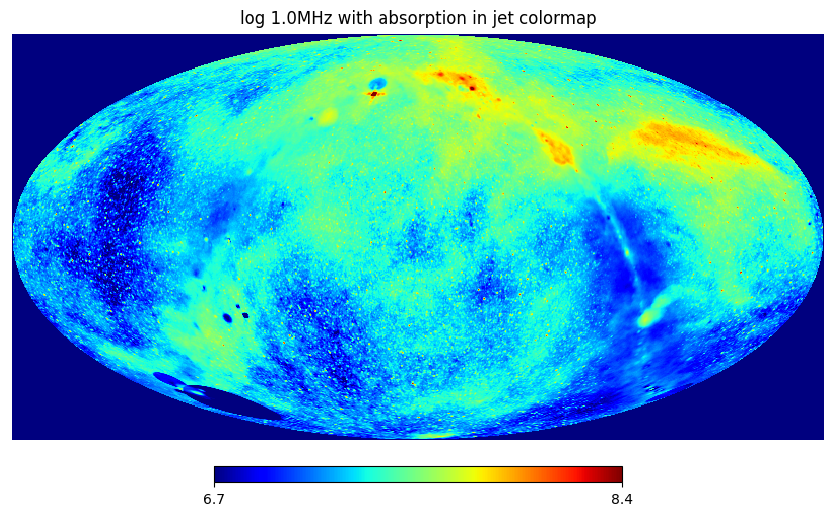

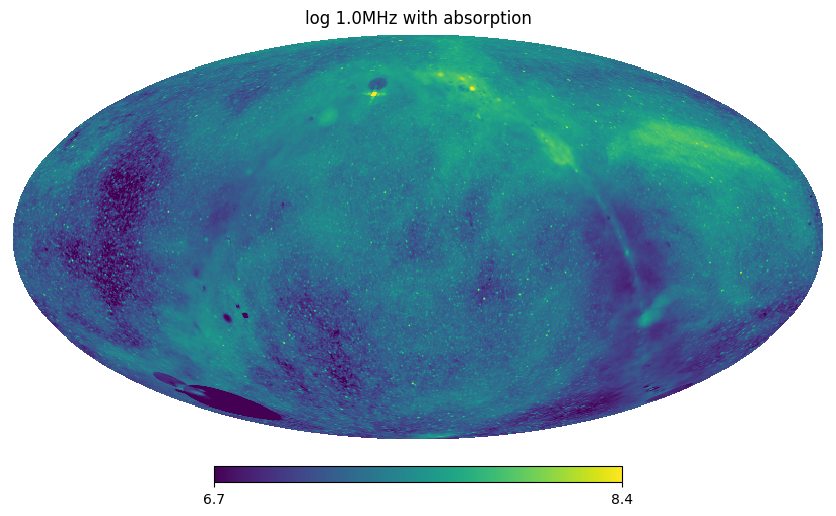

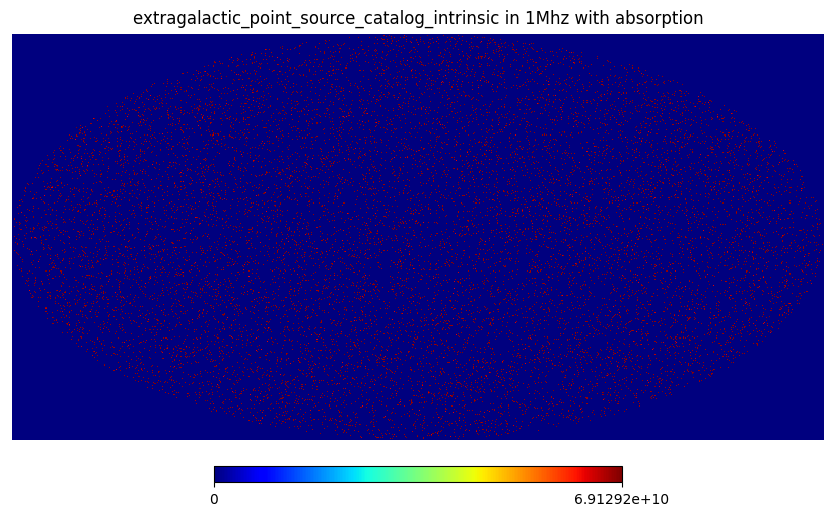

In [4]:
hp.mollview(np.log10(skymap),cmap = plt.cm.jet,min=6.7,max=8.4, title='log 1.0MHz with absorption in jet colormap')
hp.mollview(np.log10(skymap),min=6.7,max=8.4, title='log 1.0MHz with absorption')
hp.mollview(extragalactic_point_source_catalog_intrinsic,norm='hist',cmap = plt.cm.jet, title='extragalactic_point_source_catalog_intrinsic in 1Mhz with absorption')
plt.show()
plt.close()

# 10Mhz

In [3]:
with h5py.File('10.0MHz_with_absorption_split.hdf5','r') as fe:
    print('fe.keys()',fe.keys())
    skymap = fe['skymap'][:]
    extragalactic_point_source_catalog_intrinsic = fe['extragalactic_point_source_catalog_intrinsic'][:] 
    print('skymap',skymap)

fe.keys() <KeysViewHDF5 ['extragalactic_point_source_catalog_intrinsic', 'skymap']>
skymap [211833.80700737 213752.15166803 211713.06159618 ...  57617.27025032
  58384.89710084  59289.99568406]


201326592


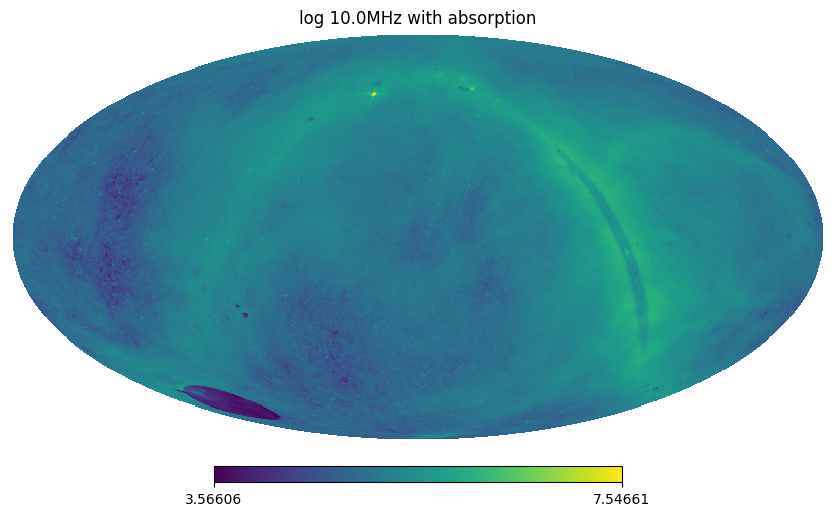

In [4]:
sky = np.fromfile('../earth_10Mhz/10.0MHz_with_absorption_split.bin', dtype=np.float64)
print(len(sky))
hp.mollview(np.log10(sky), title='log 10.0MHz with absorption')
plt.show()

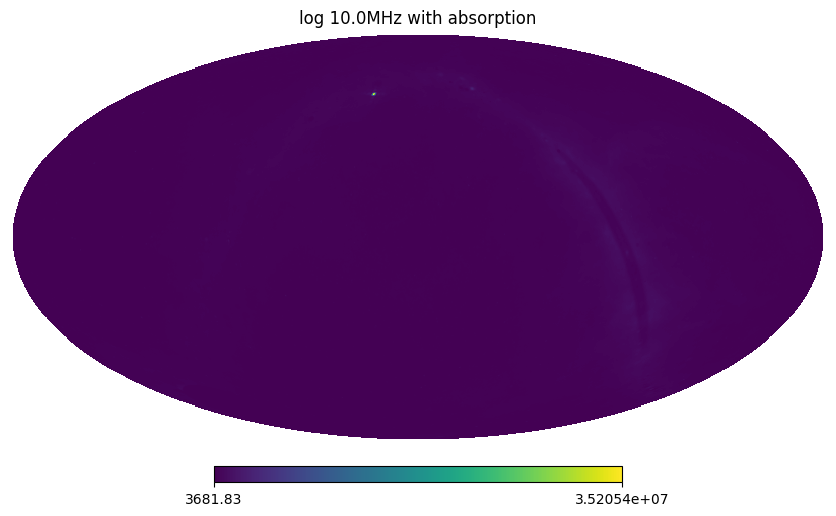

In [5]:
hp.mollview(sky, title='log 10.0MHz with absorption')
plt.show()

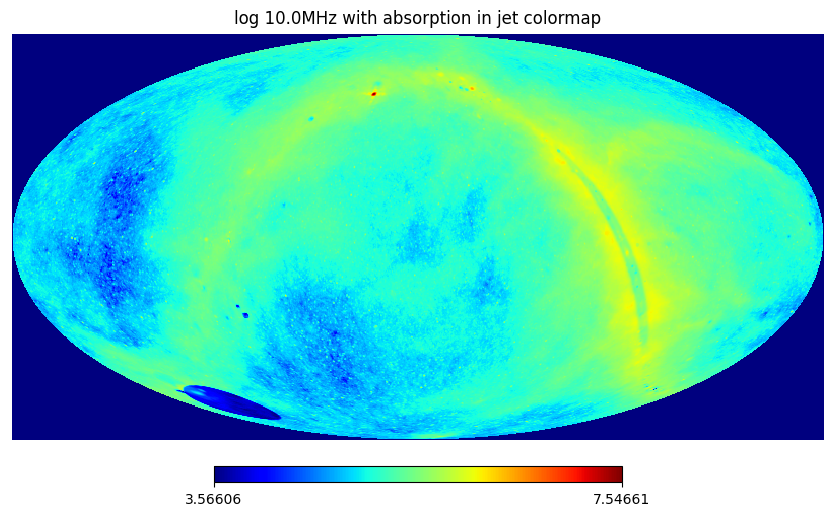

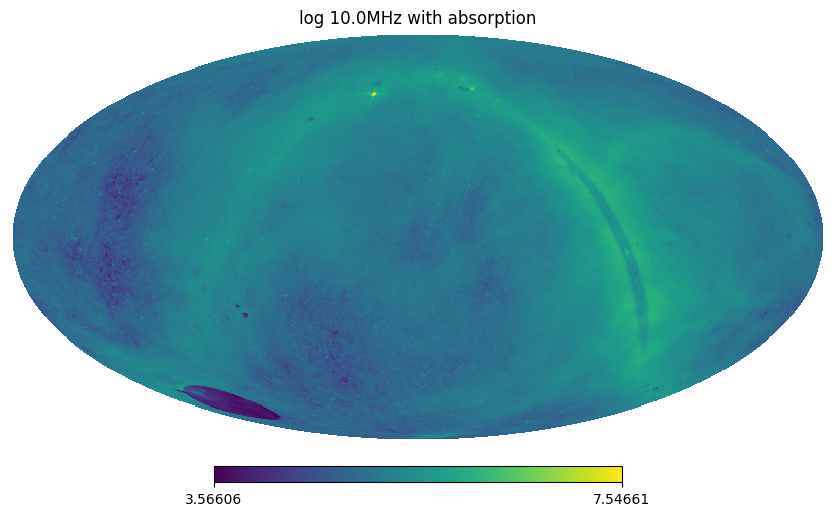

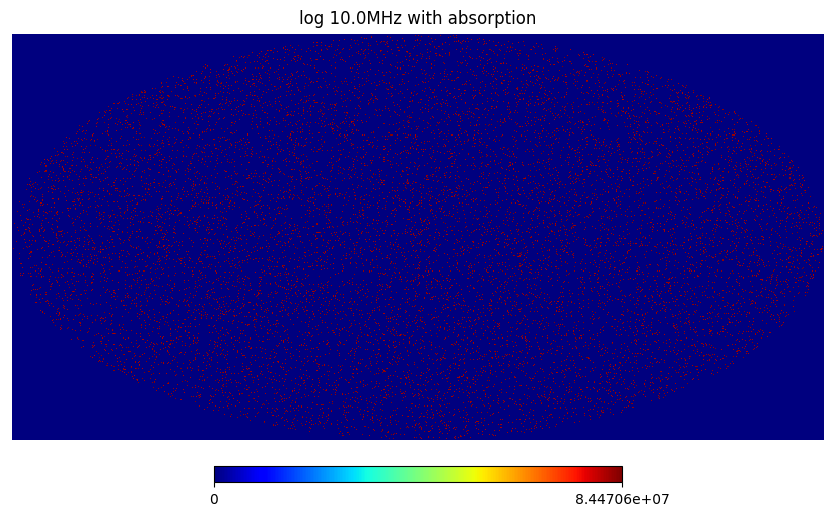

In [45]:
hp.mollview(np.log10(skymap),cmap = plt.cm.jet, title='log 10.0MHz with absorption in jet colormap')
hp.mollview(np.log10(skymap), title='log 10.0MHz with absorption')
hp.mollview(extragalactic_point_source_catalog_intrinsic,norm='hist',cmap = plt.cm.jet, title='log 10.0MHz with absorption')
plt.show()
plt.close()

# 30Mhz

In [31]:
with h5py.File('exp30.0MHz_sky_map_with_absorption.hdf5','r') as fe:
    # fe.keys() <KeysViewHDF5 ['MW_total_optical_depth', 'critical_distance', 'data', 'free-free', 
    # 'interpolate_skymap_by_obs', 'only_MW_foreground', 'pixel_number', 'smooth_absorb', 
    # 'spectral_index', 'transmittance', 'unabsrob_skymap_by_model']>
    print('fe.keys()',fe.keys())
    skymap = fe['interpolate_skymap_by_obs'][:]
    print('skymap',len(skymap))
    data = fe['data'][:]
    print('data',len(data))
    smooth_absorb = fe['smooth_absorb'][:]
    print('smooth_absorb',len(smooth_absorb))

fe.keys() <KeysViewHDF5 ['MW_total_optical_depth', 'critical_distance', 'data', 'free-free', 'interpolate_skymap_by_obs', 'only_MW_foreground', 'pixel_number', 'smooth_absorb', 'spectral_index', 'transmittance', 'unabsrob_skymap_by_model']>
skymap 3145728
data 3145728
smooth_absorb 3145728


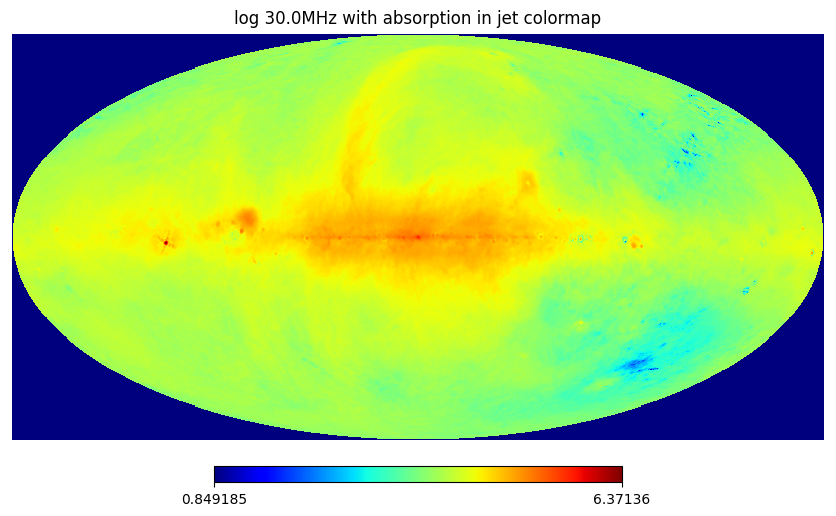

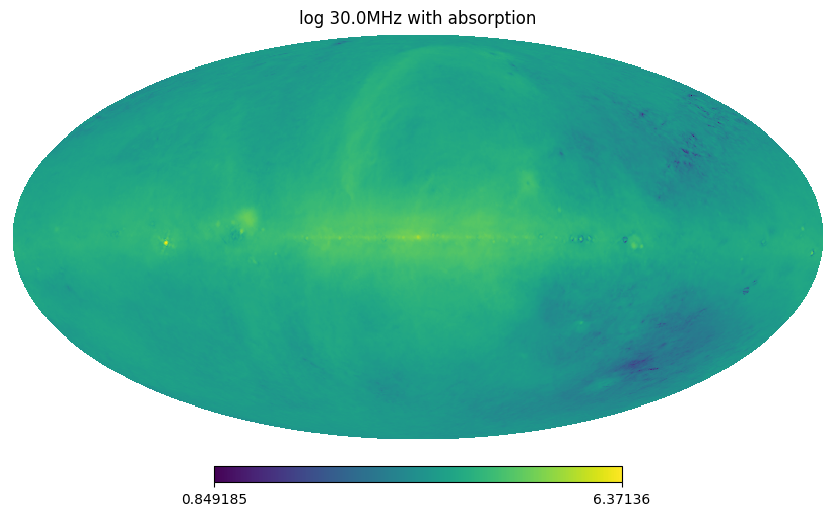

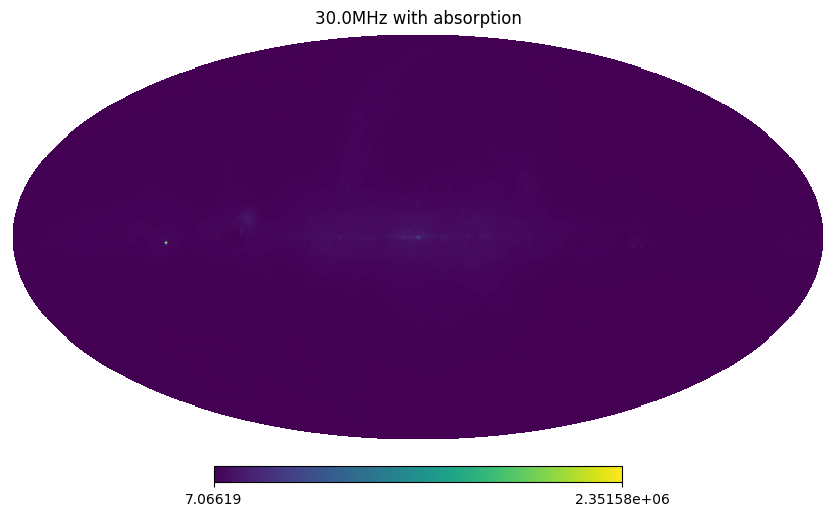

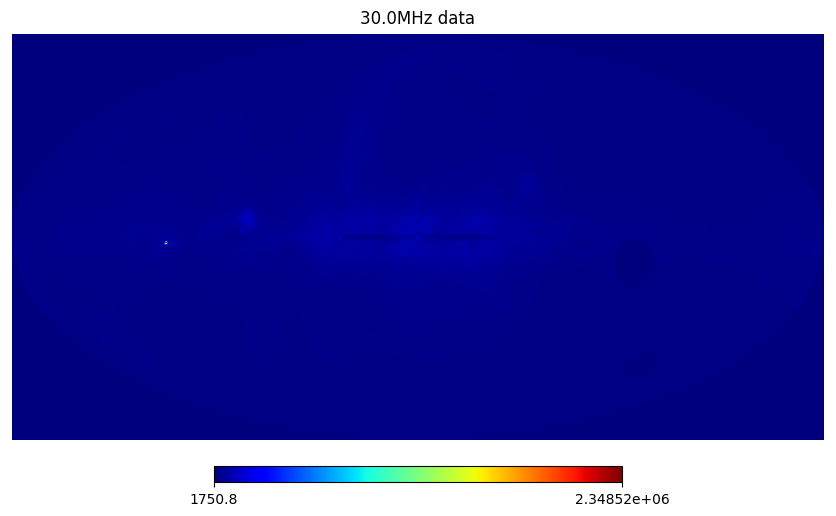

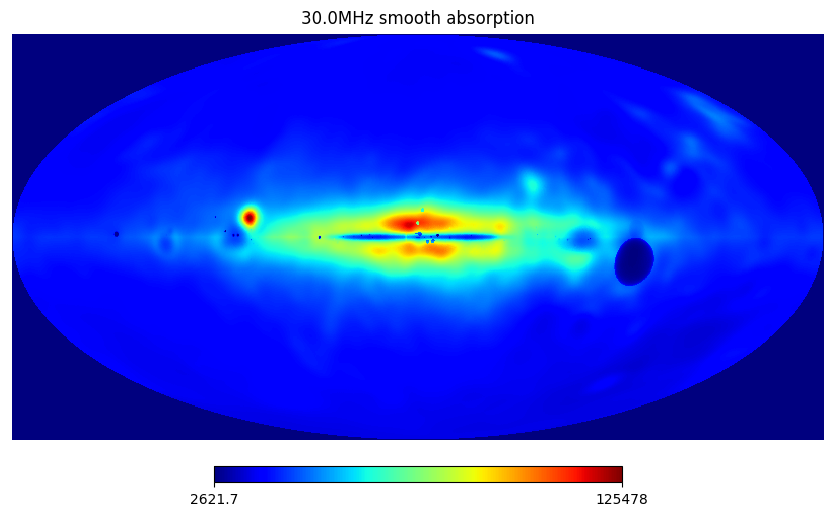

In [32]:
hp.mollview(np.log10(skymap),cmap = plt.cm.jet, title='log 30.0MHz with absorption in jet colormap')
hp.mollview(np.log10(skymap),title='log 30.0MHz with absorption')
hp.mollview(skymap, title='30.0MHz with absorption')
hp.mollview(data,cmap = plt.cm.jet, title='30.0MHz data')
hp.mollview(smooth_absorb,cmap = plt.cm.jet, title='30.0MHz smooth absorption')
plt.show()
plt.close()

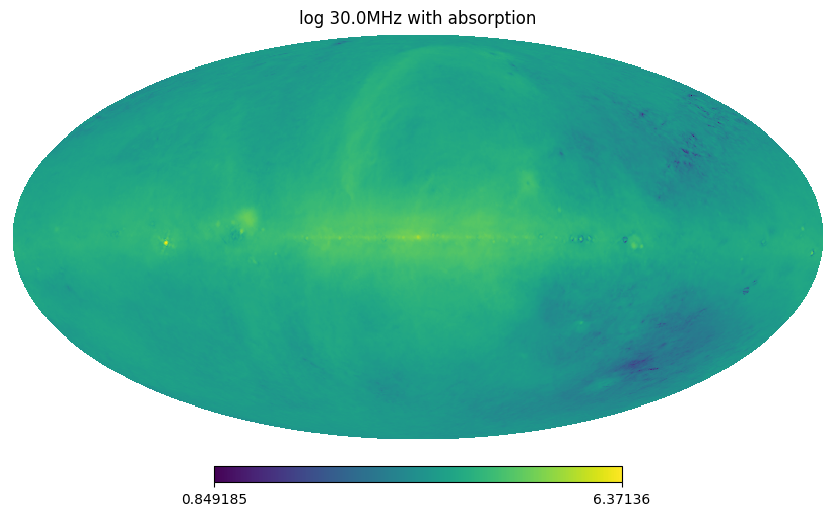

In [26]:
hp.mollview(np.log10(skymap), title='log 30.0MHz with absorption')
plt.show()
plt.close()

# 保存成Bin文件

import h5py
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import os

def save_hdf5_skymap_to_ring_bin(h5_path, dataset, out_bin):
    with h5py.File(h5_path, "r") as f:
        print("keys:", list(f.keys()))
        skymap = f[dataset][:]

    skymap = np.asarray(skymap)
    npix = skymap.size
    nside = hp.npix2nside(npix)

    print("dataset:", dataset)
    print("nside:", nside)
    print("npix:", npix)
    print("dtype:", skymap.dtype)
    print("min:", np.nanmin(skymap))
    print("max:", np.nanmax(skymap))
    print("mean:", np.nanmean(skymap))

    skymap = np.nan_to_num(skymap, nan=0.0, posinf=0.0, neginf=0.0)
    skymap = skymap.astype("<f4", copy=False)

    os.makedirs(os.path.dirname(out_bin), exist_ok=True)
    skymap.tofile(out_bin)

    expected_bytes = npix * 4
    actual_bytes = os.path.getsize(out_bin)
    print("out:", out_bin)
    print("expected bytes:", expected_bytes)
    print("actual bytes:", actual_bytes)

    assert expected_bytes == actual_bytes

    # RING 顺序检查图
    hp.mollview(
        np.log10(np.maximum(skymap, 1e-30)),
        nest=False,
        cmap=plt.cm.jet,
        title=f"{dataset}, RING, nside={nside}"
    )
    plt.show()


save_hdf5_skymap_to_ring_bin(
    h5_path="1.0MHz_with_absorption.hdf5",
    dataset="skymap",
    out_bin="earth_1Mhz/B_1M.bin"
)

save_hdf5_skymap_to_ring_bin(
    h5_path="10.0MHz_with_absorption.hdf5",
    dataset="skymap",
    out_bin="earth_10Mhz/B_10M.bin"
)